# Frozen WildFireVQA Shot-Count Benchmark (0-10)

This notebook evaluates one frozen pretrained vision-language model with every prompt shot count from 0 through 10. It never trains on WildFireVQA: no optimizer, backward pass, adapter, or parameter update is created. Support examples and test queries are separated by image. For a fair paired comparison, each query receives one deterministic ordered support pool and the `k`-shot run uses its first `k` examples.

The report includes exact match, normalized exact match, BLEU-4, ROUGE-L, answer rate, output length, latency, bootstrap confidence intervals, category-level results, and paired changes from zero-shot.


In [3]:
!pip install -q -U 'transformers>=4.49.0' bitsandbytes accelerate kagglehub qwen-vl-utils sentencepiece


In [4]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

login(token=UserSecretsClient().get_secret("HF_TOKEN"))

In [5]:
import os
import re
import json
import math
import random
import time
from pathlib import Path
from collections import Counter
from typing import Any, Dict, List

os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import torch
import kagglehub

from transformers import (
    AutoProcessor,
    BitsAndBytesConfig,
    Qwen2_5_VLForConditionalGeneration,
)
from qwen_vl_utils import process_vision_info

print('Torch:', torch.__version__)
print('CUDA devices:', torch.cuda.device_count())
for index in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(index)
    print(f'GPU {index}: {props.name} ({props.total_memory / 2**30:.1f} GiB)')


Torch: 2.11.0+cu128
CUDA devices: 2
GPU 0: Tesla T4 (14.6 GiB)
GPU 1: Tesla T4 (14.6 GiB)


In [6]:
class CFG:
    KAGGLE_DATASET = 'caseypiere/wildfire-vqa'
    FLAME3_KAGGLE_DATASET = 'brycehopkins/flame-3-computer-vision-subset-sycan-marsh'
    DATA_ROOT = Path('/kaggle/input/datasets/caseypiere/wildfire-vqa')
    FLAME3_ROOT = None
    FLAME3_MARKER_DIR = 'Flame 3 Computer Vision Sets'
    ANNOTATION_FILE = None
    DATA_SOURCE = 'kagglehub'
    ALLOWED_SITE_PREFIX = 'Sycan'

    MODEL = 'Qwen/Qwen2.5-VL-3B-Instruct'
    USE_4BIT = True
    SHOT_COUNTS = tuple(range(0, 11))
    TEST_FRAC = 0.10
    MAX_EVAL_SAMPLES = 200  # 11 runs per row; set None for the complete test split.
    BOOTSTRAP_SAMPLES = 1000
    RESUME_PARTIAL_RESULTS = True
    MAX_NEW_TOKENS = 32
    IMAGE_SIZE = 224
    SEED = 42
    OUTPUT_DIR = Path('/kaggle/working/firevlm_frozen_shot_benchmark_qwen25vl_3b')

CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
random.seed(CFG.SEED)
np.random.seed(CFG.SEED)
torch.manual_seed(CFG.SEED)


In [7]:
def load_json_any(path: Path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def flatten_checkpoint_json(obj: Dict[str, Any], source_name: str) -> List[Dict[str, Any]]:
    rows = []
    items = obj.get('items', {})
    if not isinstance(items, dict):
        return rows
    for ck, entry in items.items():
        if not isinstance(entry, dict):
            continue
        meta = entry.get('meta', {})
        if not isinstance(meta, dict):
            continue
        row = dict(meta)
        row['gt_answer'] = entry.get('human_answer', row.get('gt_answer', row.get('answer')))
        row['checkpoint_key'] = ck
        row['source_input'] = source_name
        rows.append(row)
    return rows

def normalize_options(x):
    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return []
        try:
            parsed = json.loads(s)
            if isinstance(parsed, list):
                return [str(v).strip() for v in parsed if str(v).strip()]
        except Exception:
            pass
        if '|' in s:
            return [v.strip() for v in s.split('|') if v.strip()]
        if ';' in s:
            return [v.strip() for v in s.split(';') if v.strip()]
        return [s]
    return []

def rows_from_json(path: Path) -> List[Dict[str, Any]]:
    obj = load_json_any(path)
    if isinstance(obj, dict) and obj.get('type') == 'checkpoint':
        return flatten_checkpoint_json(obj, str(path))
    if isinstance(obj, dict):
        for key in ['items', 'annotations', 'data', 'records', 'questions']:
            if isinstance(obj.get(key), list):
                return [r for r in obj[key] if isinstance(r, dict)]
    if isinstance(obj, list):
        return [r for r in obj if isinstance(r, dict)]
    return []

def discover_annotation_files(root: Path):
    exts = ['*.json', '*.jsonl', '*.csv', '*.parquet']
    files = []
    if root.exists():
        for ext in exts:
            files.extend(root.rglob(ext))
    priority = ('vqa', 'question', 'answer', 'annotation', 'response', 'train', 'val')
    return sorted(files, key=lambda p: (not any(w in p.name.lower() for w in priority), len(str(p))))

def load_rows_from_files():
    if CFG.ANNOTATION_FILE:
        files = [Path(CFG.ANNOTATION_FILE)]
    else:
        files = discover_annotation_files(CFG.DATA_ROOT)
    if not files:
        raise FileNotFoundError(f'No annotation files found under {CFG.DATA_ROOT}')

    all_rows = []
    for p in files:
        try:
            if p.suffix.lower() == '.json':
                rows = rows_from_json(p)
            elif p.suffix.lower() == '.jsonl':
                with open(p, 'r', encoding='utf-8') as f:
                    rows = [json.loads(line) for line in f if line.strip()]
            elif p.suffix.lower() == '.csv':
                rows = pd.read_csv(p).to_dict('records')
            elif p.suffix.lower() == '.parquet':
                rows = pd.read_parquet(p).to_dict('records')
            else:
                rows = []
            for r in rows:
                r.setdefault('source_input', str(p))
            all_rows.extend(rows)
        except Exception as e:
            print('[WARN] failed to load', p, repr(e))
    return all_rows

def load_rows_from_kagglehub():
    if kagglehub is None:
        raise ImportError('kagglehub is unavailable.')
    try:
        dataset_root = Path(kagglehub.dataset_download(CFG.KAGGLE_DATASET))
        CFG.DATA_ROOT = dataset_root
    except Exception as e:
        print('[WARN] kagglehub.dataset_download failed; using local path:', repr(e))
    return load_rows_from_files()

if CFG.DATA_SOURCE == 'kagglehub':
    raw_rows = load_rows_from_kagglehub()
else:
    raw_rows = load_rows_from_files()

print(f'Loaded {len(raw_rows):,} raw annotation rows.')


Loaded 207,306 raw annotation rows.


In [8]:
def get_first(row, names, default=None):
    for n in names:
        if n in row and row[n] is not None:
            return row[n]
    return default

def normalize_answer_text(x):
    if isinstance(x, list):
        vals = [normalize_answer_text(v) for v in x]
        vals = [v for v in vals if v]
        return Counter(vals).most_common(1)[0][0] if vals else ''
    if isinstance(x, dict):
        for key in ['answer', 'label', 'text', 'gt_answer', 'human_answer']:
            if key in x:
                return normalize_answer_text(x[key])
        return json.dumps(x, sort_keys=True)
    return re.sub(r'\s+', ' ', str(x).strip()) if x is not None else ''

records = []
for row in raw_rows:
    question = get_first(row, ['question', 'query', 'prompt'], '')
    answer = get_first(row, ['gt_answer', 'answer', 'human_answer', 'label', 'target'], '')
    options = normalize_options(get_first(row, ['options', 'choices', 'candidate_answers'], []))
    rgb_path = get_first(row, ['rgb_path', 'image_path', 'image', 'img_path', 'rgb', 'file_name', 'filename'], None)
    thermal_path = get_first(row, ['thermal_path', 'thermal', 'ir_path', 'thermal_image', 'thermal_jpg'], None)
    temp_summary = get_first(row, ['temp_summary', 'temperature_summary', 'thermal_summary'], None)

    rec = {
        'image_id': str(get_first(row, ['image_id', 'frame_id', 'id'], '')),
        'question_id': str(get_first(row, ['question_id', 'qid'], '')),
        'category': str(get_first(row, ['category', 'question_category', 'group'], 'unknown')),
        'question': str(question).strip(),
        'answer': normalize_answer_text(answer),
        'options': options,
        'rgb_path': rgb_path,
        'thermal_path': thermal_path,
        'temp_summary': temp_summary if isinstance(temp_summary, dict) else None,
        'source_input': str(get_first(row, ['source_input'], '')),
    }
    if rec['question'] and rec['answer']:
        records.append(rec)

df = pd.DataFrame(records).drop_duplicates(
    subset=['image_id', 'question_id', 'question', 'answer', 'rgb_path', 'thermal_path']
).reset_index(drop=True)

# ---------------------------------------------------------------
# 1) Which FLAME-3 site does each annotation row come from?
# ---------------------------------------------------------------
MARKER = CFG.FLAME3_MARKER_DIR

def site_of(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return 'unknown'
    parts = str(p).replace('\\', '/').split('/')
    if MARKER in parts:
        i = parts.index(MARKER)
        if i + 1 < len(parts):
            return parts[i + 1]
    return 'unknown'

df['site'] = df['rgb_path'].apply(site_of)
print('Rows per site in annotations:')
print(df['site'].value_counts().to_string())

# Keep only sites present in the Kaggle subset (Sycan*).
df = df[df['site'].str.startswith(CFG.ALLOWED_SITE_PREFIX)].reset_index(drop=True)
print(f'\nRows after site filter ({CFG.ALLOWED_SITE_PREFIX}*): {len(df):,}')

# ---------------------------------------------------------------
# 2) Locate the folder on Kaggle that directly contains Fire/ and No Fire/
# ---------------------------------------------------------------
def discover_flame_base():
    roots = []
    if CFG.FLAME3_ROOT is not None:
        roots.append(Path(CFG.FLAME3_ROOT))
    if kagglehub is not None:
        try:
            roots.append(Path(kagglehub.dataset_download(CFG.FLAME3_KAGGLE_DATASET)))
        except Exception as e:
            print('[WARN] kagglehub flame3 download failed:', repr(e))
    if Path('/kaggle/input').exists():
        roots.append(Path('/kaggle/input'))
    for r in roots:
        if not r.exists():
            continue
        hits = sorted([p for p in r.rglob('Fire') if p.is_dir()], key=lambda p: len(p.parts))
        if hits:
            return hits[0].parent
    return None

FLAME_BASE = discover_flame_base()
assert FLAME_BASE is not None, 'Could not find a folder containing Fire/ in the FLAME-3 dataset.'
print('\nFLAME base folder:', FLAME_BASE)
print('Contents:', sorted(p.name for p in FLAME_BASE.iterdir()))

# ---------------------------------------------------------------
# 3) Strict structural path mapping (NO filename-only fallback)
#    annotation: .../<site>/Images/<Fire|No Fire>/<RGB|Thermal>/<sub>/<file>
#    kaggle:     <BASE>/<Fire|No Fire>/<RGB|Thermal>/<sub'>/<file>
# ---------------------------------------------------------------
SUBDIR_MAP = {
    ('RGB', 'Corrected FOV'): ('RGB', 'Corrected FOV'),
    ('RGB', 'Raw'):           ('RGB', 'Raw'),
    ('Thermal', 'JPG'):       ('Thermal', 'Raw JPG'),
    ('Thermal', 'Raw JPG'):   ('Thermal', 'Raw JPG'),
    ('Thermal', 'TIFF'):      ('Thermal', 'Celsius TIFF'),
    ('Thermal', 'Celsius TIFF'): ('Thermal', 'Celsius TIFF'),
}

def resolve_path(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    parts = str(value).replace('\\', '/').split('/')
    cls = next((c for c in ('Fire', 'No Fire') if c in parts), None)
    if cls is None:
        return None
    i = len(parts) - 1 - parts[::-1].index(cls)   # last occurrence of the class folder
    try:
        modality, sub, fname = parts[i + 1], parts[i + 2], parts[-1]
    except IndexError:
        return None
    m, s = SUBDIR_MAP.get((modality, sub), (modality, sub))
    cand = FLAME_BASE / cls / m / s / fname
    return str(cand) if cand.exists() else None

df['rgb_resolved'] = df['rgb_path'].apply(resolve_path)
df['thermal_resolved'] = df['thermal_path'].apply(resolve_path)

print(f'\nRGB resolved:     {df["rgb_resolved"].notna().mean():.1%}')
print(f'Thermal resolved: {df["thermal_resolved"].notna().mean():.1%}')

# Require BOTH modalities, and they must be different files
df = df[df['rgb_resolved'].notna() & df['thermal_resolved'].notna()]
df = df[df['rgb_resolved'] != df['thermal_resolved']].reset_index(drop=True)

# If two sites (e.g. Sycan_2A and Sycan_2D) map onto the same Kaggle file, the pairing is ambiguous -> drop
n_sites = df.groupby('rgb_resolved')['site'].nunique()
ambiguous = n_sites[n_sites > 1].index
if len(ambiguous):
    print(f'[WARN] {len(ambiguous):,} images are shared by multiple sites -> dropping those rows')
    df = df[~df['rgb_resolved'].isin(ambiguous)].reset_index(drop=True)

print(f'\nFinal rows with valid, distinct RGB + thermal: {len(df):,}')
print('Unique RGB images:', df['rgb_resolved'].nunique())
print('RGB == thermal fraction (must be 0):', (df['rgb_resolved'] == df['thermal_resolved']).mean())
assert len(df) > 0, 'No rows resolved. Check FLAME_BASE contents above.'
df[['site', 'question', 'answer', 'rgb_resolved', 'thermal_resolved']].head()

Rows per site in annotations:
site
Shoetank     120360
Wilamette     61846
Sycan         25092

Rows after site filter (Sycan*): 25,092

FLAME base folder: /kaggle/input/datasets/brycehopkins/flame-3-computer-vision-subset-sycan-marsh/FLAME 3 CV Dataset (Sycan Marsh)
Contents: ['Fire', 'No Fire']

RGB resolved:     100.0%
Thermal resolved: 100.0%

Final rows with valid, distinct RGB + thermal: 25,092
Unique RGB images: 480
RGB == thermal fraction (must be 0): 0.0


,site,question,answer,rgb_resolved,thermal_resolved
0,Sycan,Are active thermal hotspots detected?,Yes,/kaggle/input/datasets/brycehopkins/flame-3-co...,/kaggle/input/datasets/brycehopkins/flame-3-co...
1,Sycan,Is smoke visible?,Yes,/kaggle/input/datasets/brycehopkins/flame-3-co...,/kaggle/input/datasets/brycehopkins/flame-3-co...
2,Sycan,Are visible flames present?,Yes,/kaggle/input/datasets/brycehopkins/flame-3-co...,/kaggle/input/datasets/brycehopkins/flame-3-co...
3,Sycan,Are any buildings or residential structures vi...,Yes,/kaggle/input/datasets/brycehopkins/flame-3-co...,/kaggle/input/datasets/brycehopkins/flame-3-co...
4,Sycan,Are natural fuel breaks like rock outcroppings...,Yes,/kaggle/input/datasets/brycehopkins/flame-3-co...,/kaggle/input/datasets/brycehopkins/flame-3-co...


In [9]:
# Support and test are split by image, preventing questions from one frame crossing splits.
unique_images = df['rgb_resolved'].unique().tolist()
rng = np.random.default_rng(CFG.SEED)
rng.shuffle(unique_images)
n_test = max(1, int(len(unique_images) * CFG.TEST_FRAC))
test_images = set(unique_images[:n_test])
support_df = df[~df['rgb_resolved'].isin(test_images)].reset_index(drop=True)
test_df = df[df['rgb_resolved'].isin(test_images)].reset_index(drop=True)
if CFG.MAX_EVAL_SAMPLES is not None and len(test_df) > CFG.MAX_EVAL_SAMPLES:
    test_df = test_df.sample(CFG.MAX_EVAL_SAMPLES, random_state=CFG.SEED).reset_index(drop=True)

assert set(support_df['rgb_resolved']).isdisjoint(set(test_df['rgb_resolved']))
assert set(support_df['thermal_resolved']).isdisjoint(set(test_df['thermal_resolved']))
assert CFG.SHOT_COUNTS == tuple(range(11)), 'Expected every shot count from 0 through 10.'
print(f'Support pool: {len(support_df):,} rows')
print(f'Held-out test: {len(test_df):,} rows')
print(f'Shot counts: {CFG.SHOT_COUNTS}')

def load_image(path):
    with Image.open(path) as image:
        return image.convert('RGB').resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE), Image.BILINEAR)

# Build one ordered support pool per query without reading test answers. All shot counts
# use prefixes of this same pool, so changing k is the only experimental difference.
def select_demonstrations(query_row, query_index):
    max_shots = max(CFG.SHOT_COUNTS)
    candidates = support_df[support_df['category'] == query_row['category']]
    if candidates['rgb_resolved'].nunique() < max_shots:
        candidates = support_df
    candidates = candidates.drop_duplicates('rgb_resolved')
    if len(candidates) < max_shots:
        raise ValueError(f'Need at least {max_shots} unique support images.')
    return candidates.sample(
        n=max_shots,
        random_state=CFG.SEED + int(query_index),
    ).to_dict('records')

support_plans = {
    int(index): select_demonstrations(row, index)
    for index, row in test_df.iterrows()
}
assert all(len(plan) == 10 for plan in support_plans.values())
print(f'Created deterministic 10-example support plans for {len(support_plans):,} queries.')


Support pool: 22,542 rows
Held-out test: 200 rows
Shot counts: (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10)
Created deterministic 10-example support plans for 200 queries.


In [10]:
if not torch.cuda.is_available():
    raise RuntimeError('Enable a Kaggle GPU accelerator.')

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
) if CFG.USE_4BIT else None

processor = AutoProcessor.from_pretrained(
    CFG.MODEL,
    min_pixels=CFG.IMAGE_SIZE * CFG.IMAGE_SIZE,
    max_pixels=CFG.IMAGE_SIZE * CFG.IMAGE_SIZE,
)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    CFG.MODEL,
    quantization_config=quantization_config,
    torch_dtype=torch.float16,
    device_map={'': 0},
    low_cpu_mem_usage=True,
)
model.eval()
for parameter in model.parameters():
    parameter.requires_grad_(False)

trainable = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print('Trainable parameters:', trainable)
assert trainable == 0, 'Few-shot baseline must not update model weights.'


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Trainable parameters: 0


In [11]:
SYSTEM_PROMPT = (
    'You are a wildfire analyst. Answer the final question from its RGB and thermal aerial '
    'images. Use the demonstrations only as examples of the task. Return only a direct, concise answer.'
)

def image_pair_content(row, label):
    return [
        {'type': 'text', 'text': f'{label} RGB image:'},
        {'type': 'image', 'image': load_image(row['rgb_resolved'])},
        {'type': 'text', 'text': f'{label} thermal image:'},
        {'type': 'image', 'image': load_image(row['thermal_resolved'])},
    ]

def build_messages(query_row, demonstrations):
    messages = [{'role': 'system', 'content': [{'type': 'text', 'text': SYSTEM_PROMPT}]}]
    for number, demo in enumerate(demonstrations, 1):
        content = image_pair_content(demo, f'Demonstration {number}')
        content.append({'type': 'text', 'text': f'Question: {demo["question"]}'})
        messages.append({'role': 'user', 'content': content})
        messages.append({'role': 'assistant', 'content': [{'type': 'text', 'text': demo['answer']}]})
    query_content = image_pair_content(query_row, 'Query')
    query_content.append({
        'type': 'text',
        'text': f'Question: {query_row["question"]}\nProvide a direct and concise answer.',
    })
    messages.append({'role': 'user', 'content': query_content})
    return messages

def prepare_inputs(messages):
    prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[prompt],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors='pt',
    )
    return inputs.to('cuda:0')


In [12]:
def simple_tokens(s: str) -> List[str]:
    return re.findall(r"\w+|[^\w\s]", str(s).lower())

def ngram_counts(tokens: List[str], n: int) -> Counter:
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1))

def sentence_bleu(reference: str, prediction: str, max_n: int = 4) -> float:
    ref = simple_tokens(reference)
    pred = simple_tokens(prediction)
    if not pred:
        return 0.0
    precisions = []
    for n in range(1, max_n + 1):
        pred_counts = ngram_counts(pred, n)
        ref_counts = ngram_counts(ref, n)
        if not pred_counts:
            precisions.append(1e-9)
            continue
        overlap = sum(min(c, ref_counts[g]) for g, c in pred_counts.items())
        precisions.append((overlap + 1) / (sum(pred_counts.values()) + 1))
    bp = 1.0 if len(pred) > len(ref) else math.exp(1 - len(ref) / max(len(pred), 1))
    return bp * math.exp(sum(math.log(p) for p in precisions) / max_n)

def lcs_len(a: List[str], b: List[str]) -> int:
    dp = [0] * (len(b) + 1)
    for x in a:
        prev = 0
        for j, y in enumerate(b, 1):
            cur = dp[j]
            if x == y:
                dp[j] = prev + 1
            else:
                dp[j] = max(dp[j], dp[j-1])
            prev = cur
    return dp[-1]

def rouge_l(reference: str, prediction: str) -> float:
    ref = simple_tokens(reference)
    pred = simple_tokens(prediction)
    if not ref or not pred:
        return 0.0
    lcs = lcs_len(ref, pred)
    prec = lcs / len(pred)
    rec = lcs / len(ref)
    if prec + rec == 0:
        return 0.0
    return 2 * prec * rec / (prec + rec)

def exact_match(reference: str, prediction: str) -> int:
    return int(str(reference).strip().lower() == str(prediction).strip().lower())

def normalize_answer(s: str) -> str:
    s = str(s).lower().strip()
    s = re.sub(r'[^a-z0-9\s<>.=+-]', ' ', s)
    s = re.sub(r'\b(a|an|the)\b', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()

def normalized_exact_match(reference: str, prediction: str) -> int:
    return int(normalize_answer(reference) == normalize_answer(prediction))

def bootstrap_mean_ci(values, seed, n_bootstrap=1000):
    values = np.asarray(values, dtype=np.float64)
    if len(values) == 0:
        return float('nan'), float('nan')
    rng = np.random.default_rng(seed)
    indices = rng.integers(0, len(values), size=(n_bootstrap, len(values)))
    means = values[indices].mean(axis=1)
    return tuple(np.quantile(means, [0.025, 0.975]).tolist())


/usr/local/lib/python3.13/dist-packages/transformers/models/qwen2_vl/image_processing_qwen2_vl.py:129: FutureWarning: Passing `min_pixels` and `max_pixels` to a processor call is deprecated and will be removed in v5.23. Pass in `size={'longest_edge': xxx, 'shortest_edge': xxx} to override the target size.`
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:957: UserWarning: inner dimension (3420) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(


Frozen inference (0-shot):   0%|          | 0/200 [00:00<?, ?it/s]

Checkpointed results through 0-shot: /kaggle/working/firevlm_frozen_shot_benchmark_qwen25vl_3b/all_shots_test_predictions.partial.csv


Frozen inference (1-shot):   0%|          | 0/200 [00:00<?, ?it/s]

Checkpointed results through 1-shot: /kaggle/working/firevlm_frozen_shot_benchmark_qwen25vl_3b/all_shots_test_predictions.partial.csv


...

Checkpointed results through 10-shot: /kaggle/working/firevlm_frozen_shot_benchmark_qwen25vl_3b/all_shots_test_predictions.partial.csv
OVERALL SHOT-COUNT COMPARISON


,num_shots,exact_match,normalized_exact_match,bleu,rouge_l,answer_rate,prediction_words,latency_seconds,input_tokens
0,0,15.00%,15.00%,0.0094,0.2438,100.00%,2.51,0.40,211
1,1,20.00%,20.00%,0.0076,0.3113,100.00%,1.73,0.51,381
2,2,23.50%,23.50%,0.0107,0.3280,100.00%,1.54,0.65,552
3,3,23.50%,23.50%,0.0122,0.3290,100.00%,1.54,0.80,723
4,4,24.50%,24.50%,0.0185,0.3362,100.00%,1.60,0.98,893
5,5,25.50%,25.50%,0.0201,0.3421,100.00%,1.66,1.14,1064
6,6,26.00%,26.00%,0.0205,0.3474,100.00%,1.67,1.33,1235
7,7,27.00%,27.00%,0.0205,0.3585,100.00%,1.66,1.54,1405
8,8,26.00%,26.00%,0.0201,0.3468,100.00%,1.66,1.76,1576
9,9,27.50%,27.50%,0.0204,0.3668,100.00%,1.64,1.99,1747


PAIRED CHANGES FROM ZERO-SHOT


,num_shots,prediction_changed_rate,exact_match_wins_vs_zero,exact_match_losses_vs_zero,exact_match_delta_vs_zero,exact_match_delta_ci_low,exact_match_delta_ci_high,normalized_exact_match_delta_vs_zero,normalized_exact_match_delta_ci_low,normalized_exact_match_delta_ci_high,bleu_delta_vs_zero,bleu_delta_ci_low,bleu_delta_ci_high,rouge_l_delta_vs_zero,rouge_l_delta_ci_low,rouge_l_delta_ci_high
0,0,0.000,0,0,0.000,0.000000,0.000,0.000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,0.440,15,5,0.050,0.010000,0.095,0.050,0.010,0.095000,-0.001773,-0.007071,0.004059,0.067473,0.020857,0.115853
2,2,0.440,19,2,0.085,0.045000,0.130,0.085,0.040,0.130000,0.001293,-0.008618,0.016040,0.084228,0.041348,0.129946
3,3,0.420,18,1,0.085,0.045000,0.130,0.085,0.045,0.125000,0.002867,-0.010696,0.019820,0.085216,0.042781,0.133752
4,4,0.470,21,2,0.095,0.050000,0.140,0.095,0.055,0.140000,0.009158,-0.006937,0.028059,0.092438,0.043633,0.139159
5,5,0.535,23,2,0.105,0.060000,0.155,0.105,0.055,0.150125,0.010782,-0.004777,0.028395,0.098295,0.050337,0.150978
6,6,0.545,24,2,0.110,0.065000,0.160,0.110,0.065,0.155125,0.011123,-0.004348,0.030597,0.103644,0.055382,0.154249
7,7,0.565,26,2,0.120,0.075000,0.170,0.120,0.075,0.170000,0.011098,-0.004669,0.032071,0.114716,0.063574,0.163718
8,8,0.525,24,2,0.110,0.065000,0.150,0.110,0.060,0.160000,0.010690,-0.005953,0.030778,0.103049,0.055120,0.157849
9,9,0.565,27,2,0.125,0.075000,0.175,0.125,0.070,0.175000,0.011059,-0.004804,0.031455,0.123049,0.070177,0.181239


Best shot count by metric: {'exact_match': 10, 'normalized_exact_match': 10, 'bleu': 6, 'rouge_l': 10}


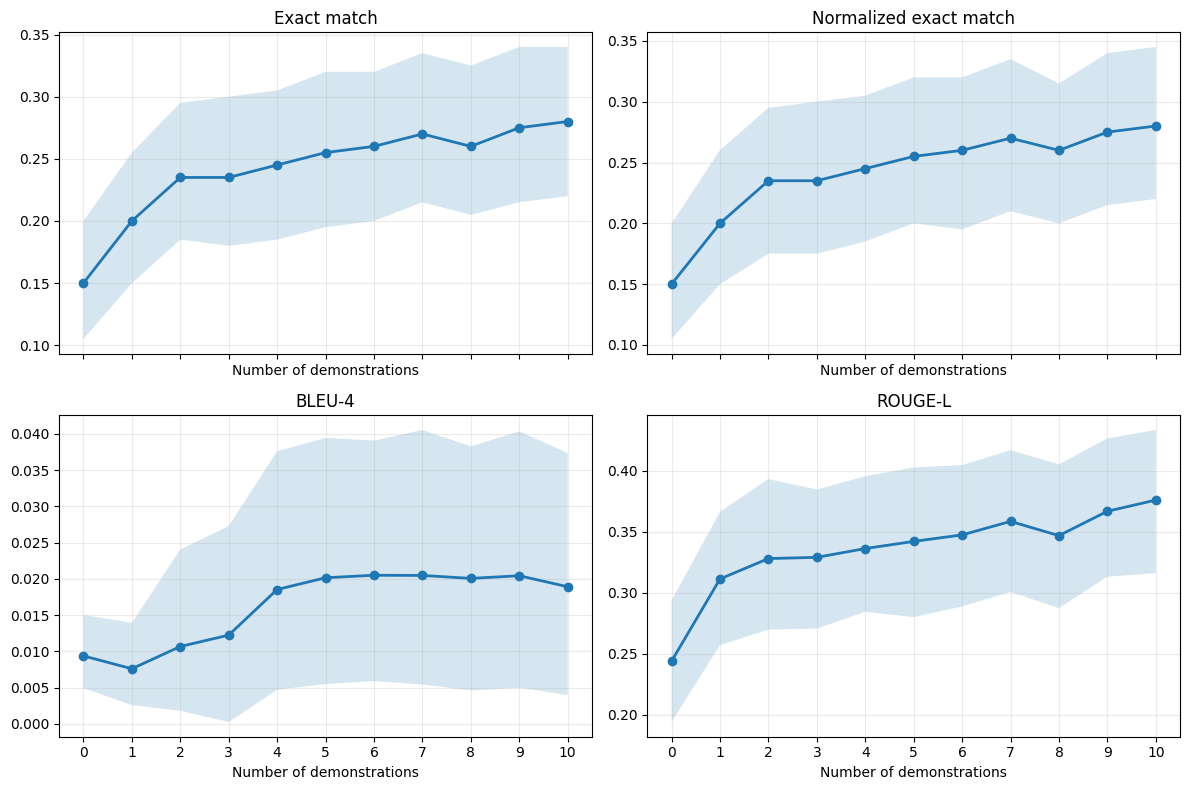

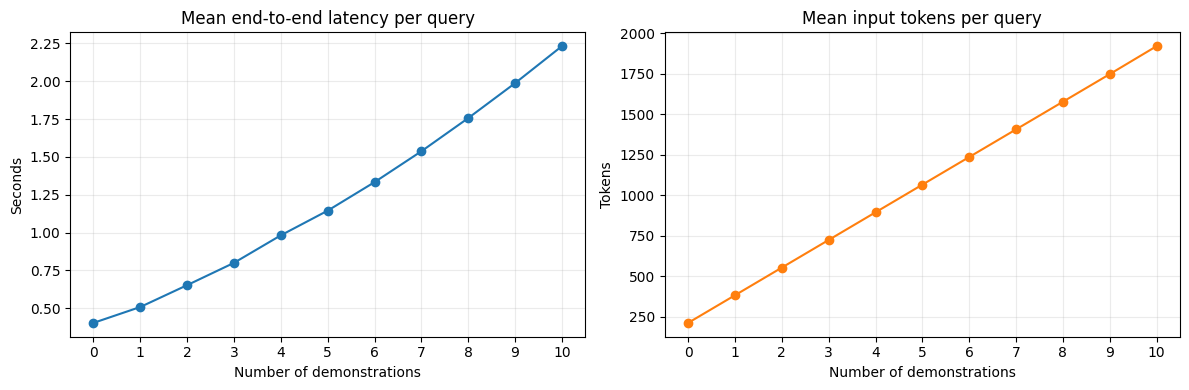

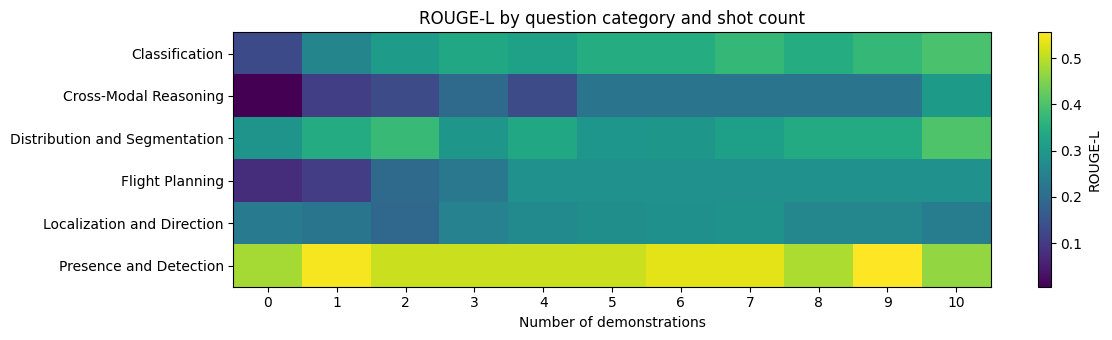

SAME-QUERY PREDICTIONS ACROSS ALL SHOT COUNTS


,question,answer,category,0,1,2,3,4,5,6,7,8,9,10
0,Where is the most intense hotspot located with...,Center,Localization and Direction,Upper right,In the center-right of the frame,Left,Center,Center,Center,Bottom-right,Bottom-right,Bottom-right,Bottom-right,Bottom-right
1,From which region of the image does the larges...,Center,Localization and Direction,Top-left,Top left,Top left,Top-left,Top-left,Top-left,Left,Left,Left,Left,Left
2,How continuous is the fuel bed in the fire's p...,Continuous,Distribution and Segmentation,The fuel bed is highly continuous along the fi...,Continuous,Continuous,Continuous,Continuous,Continuous,Continuous,Continuous,Continuous,Continuous,Continuous
3,What is the temperature of the hottest part of...,>500,Cross-Modal Reasoning,400,200,300,400,100,100,100,100,100,100,100
4,What is the current level of safety risk of th...,Medium risk,Flight Planning,High,High,High,High,High,High,High,High,High,High,High
5,What percentage of the full scene exceeds 200 ...,<5%,Distribution and Segmentation,50%,50%,50%,50%,50%,0%,0%,0%,0%,0%,0%
6,From which region of the image does the larges...,Bottom-left,Localization and Direction,Top-left,Top left,Top-left,Top-left,Top-left,Top-left,Top-left,Top-left,Top-left,Top-left,Top-left
7,How many emergency vehicles are visible in the...,0,Presence and Detection,0,0,0,0,0,0,0,0,0,0,0
8,What is the primary fuel type on the ground by...,Grass,Classification,Vegetation,Vegetation,Vegetation,Vegetation,Vegetation,Vegetation,Vegetation,Grass,Vegetation,Grass,Grass
9,Are any buildings or residential structures vi...,Yes,Presence and Detection,No,Yes,No,No,No,No,No,No,No,No,No


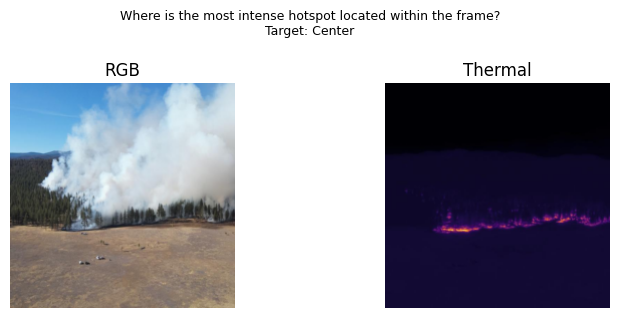

num_shots,0,1,2,3,4,5,6,7,8,9,10
query_id,,,,,,,,,,,
0,Upper right,In the center-right of the frame,Left,Center,Center,Center,Bottom-right,Bottom-right,Bottom-right,Bottom-right,Bottom-right


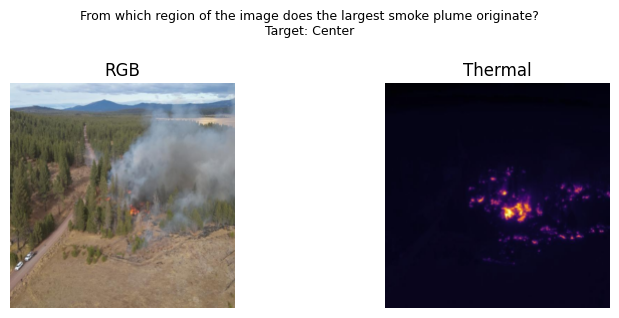

num_shots,0,1,2,3,4,5,6,7,8,9,10
query_id,,,,,,,,,,,
1,Top-left,Top left,Top left,Top-left,Top-left,Top-left,Left,Left,Left,Left,Left


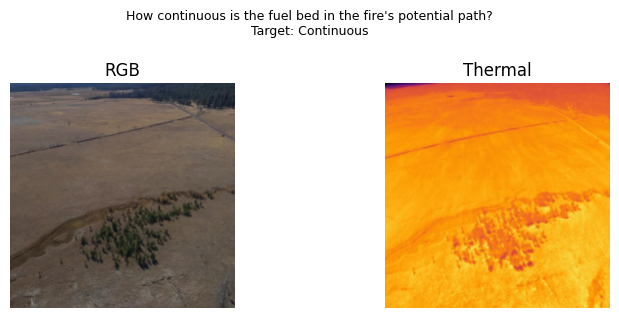

num_shots,0,1,2,3,4,5,6,7,8,9,10
query_id,,,,,,,,,,,
2,The fuel bed is highly continuous along the fi...,Continuous,Continuous,Continuous,Continuous,Continuous,Continuous,Continuous,Continuous,Continuous,Continuous


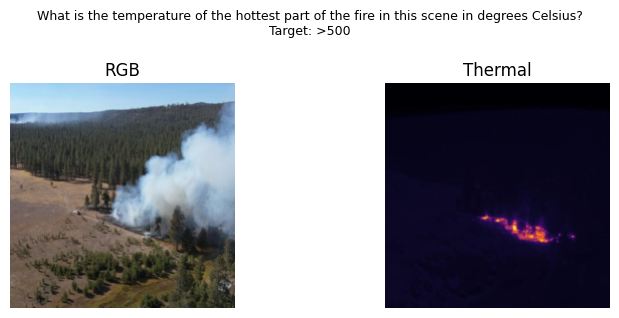

num_shots,0,1,2,3,4,5,6,7,8,9,10
query_id,,,,,,,,,,,
3,400,200,300,400,100,100,100,100,100,100,100


In [13]:
# Warm up kernels once so the zero-shot timing is not charged for one-time CUDA setup.
warmup_row = test_df.iloc[0]
warmup_inputs = prepare_inputs(build_messages(warmup_row, []))
with torch.inference_mode():
    _ = model.generate(**warmup_inputs, max_new_tokens=1, do_sample=False, num_beams=1)
torch.cuda.synchronize()
del warmup_inputs, _
torch.cuda.empty_cache()

partial_path = CFG.OUTPUT_DIR / 'all_shots_test_predictions.partial.csv'
rows = []
completed_shots = set()
if CFG.RESUME_PARTIAL_RESULTS and partial_path.exists():
    partial = pd.read_csv(partial_path)
    expected_ids = set(test_df.index.astype(int))
    expected_questions = test_df['question'].to_dict()
    for saved_shot, saved_group in partial.groupby('num_shots'):
        saved_ids = set(saved_group['query_id'].astype(int))
        questions_match = all(
            str(row.question) == str(expected_questions[int(row.query_id)])
            for row in saved_group.itertuples()
            if int(row.query_id) in expected_questions
        )
        if (
            int(saved_shot) in CFG.SHOT_COUNTS
            and saved_ids == expected_ids
            and questions_match
            and len(saved_group) == len(test_df)
        ):
            rows.extend(saved_group.to_dict('records'))
            completed_shots.add(int(saved_shot))
    print('Resuming completed shot counts:', sorted(completed_shots))
with torch.inference_mode():
    for shot_count in CFG.SHOT_COUNTS:
        if shot_count in completed_shots:
            continue
        iterator = tqdm(
            test_df.iterrows(),
            total=len(test_df),
            desc=f'Frozen inference ({shot_count}-shot)',
        )
        for query_index, query_row in iterator:
            demos = support_plans[int(query_index)][:shot_count]
            messages = build_messages(query_row, demos)
            torch.cuda.synchronize()
            started = time.perf_counter()
            inputs = prepare_inputs(messages)
            generated = model.generate(
                **inputs,
                max_new_tokens=CFG.MAX_NEW_TOKENS,
                do_sample=False,
                num_beams=1,
            )
            torch.cuda.synchronize()
            latency = time.perf_counter() - started
            trimmed = generated[:, inputs['input_ids'].shape[1]:]
            prediction = processor.batch_decode(
                trimmed,
                skip_special_tokens=True,
                clean_up_tokenization_spaces=False,
            )[0].strip().split('\n')[0].strip()

            target = query_row['answer']
            rows.append({
                'query_id': int(query_index),
                'num_shots': int(shot_count),
                'category': query_row['category'],
                'question': query_row['question'],
                'target': target,
                'prediction': prediction,
                'exact_match': exact_match(target, prediction),
                'normalized_exact_match': normalized_exact_match(target, prediction),
                'bleu': sentence_bleu(target, prediction),
                'rouge_l': rouge_l(target, prediction),
                'answer_rate': int(bool(prediction)),
                'prediction_words': len(simple_tokens(prediction)),
                'latency_seconds': latency,
                'input_tokens': int(inputs['attention_mask'].sum().item()),
                'images_in_prompt': 2 * (shot_count + 1),
                'support_image_paths': json.dumps([d['rgb_resolved'] for d in demos]),
            })
            del messages, inputs, generated, trimmed
        pd.DataFrame(rows).to_csv(partial_path, index=False)
        print(f'Checkpointed results through {shot_count}-shot: {partial_path}')

results = pd.DataFrame(rows).sort_values(['num_shots', 'query_id']).reset_index(drop=True)
expected_rows = len(test_df) * len(CFG.SHOT_COUNTS)
assert len(results) == expected_rows
assert results.groupby('query_id')['num_shots'].nunique().eq(11).all()
results.to_csv(CFG.OUTPUT_DIR / 'all_shots_test_predictions.csv', index=False)

metric_columns = [
    'exact_match', 'normalized_exact_match', 'bleu', 'rouge_l',
    'answer_rate', 'prediction_words', 'latency_seconds', 'input_tokens',
]
summary_rows = []
for shot_count, group in results.groupby('num_shots', sort=True):
    record = {'num_shots': int(shot_count), 'n_samples': int(len(group))}
    for metric in metric_columns:
        values = group[metric].to_numpy(dtype=np.float64)
        low, high = bootstrap_mean_ci(
            values, CFG.SEED + int(shot_count) * 100 + metric_columns.index(metric),
            CFG.BOOTSTRAP_SAMPLES,
        )
        record[metric] = float(values.mean())
        record[f'{metric}_ci_low'] = float(low)
        record[f'{metric}_ci_high'] = float(high)
    summary_rows.append(record)
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(CFG.OUTPUT_DIR / 'shot_summary.csv', index=False)

category_df = (
    results.groupby(['category', 'num_shots'])[metric_columns]
    .mean()
    .reset_index()
)
category_df.to_csv(CFG.OUTPUT_DIR / 'shot_category_summary.csv', index=False)

# Paired per-query deltas isolate shot-count effects from differences in test composition.
zero = results[results['num_shots'] == 0].set_index('query_id')
paired_rows = []
for shot_count in CFG.SHOT_COUNTS:
    current = results[results['num_shots'] == shot_count].set_index('query_id')
    record = {
        'num_shots': int(shot_count),
        'prediction_changed_rate': float((current['prediction'] != zero['prediction']).mean()),
        'exact_match_wins_vs_zero': int(((current['exact_match'] > zero['exact_match'])).sum()),
        'exact_match_losses_vs_zero': int(((current['exact_match'] < zero['exact_match'])).sum()),
    }
    for metric in ['exact_match', 'normalized_exact_match', 'bleu', 'rouge_l']:
        delta = (current[metric] - zero[metric]).to_numpy(dtype=np.float64)
        low, high = bootstrap_mean_ci(
            delta, CFG.SEED + 10000 + int(shot_count) * 100 + metric_columns.index(metric),
            CFG.BOOTSTRAP_SAMPLES,
        )
        record[f'{metric}_delta_vs_zero'] = float(delta.mean())
        record[f'{metric}_delta_ci_low'] = float(low)
        record[f'{metric}_delta_ci_high'] = float(high)
    paired_rows.append(record)
paired_df = pd.DataFrame(paired_rows)
paired_df.to_csv(CFG.OUTPUT_DIR / 'shot_vs_zero_paired_deltas.csv', index=False)

best_shots = {
    metric: int(summary_df.loc[summary_df[metric].idxmax(), 'num_shots'])
    for metric in ['exact_match', 'normalized_exact_match', 'bleu', 'rouge_l']
}
comparison_report = {
    'model': CFG.MODEL,
    'shot_counts': list(CFG.SHOT_COUNTS),
    'weight_updates': 0,
    'test_samples_per_shot': int(len(test_df)),
    'total_generations': int(len(results)),
    'bootstrap_samples': CFG.BOOTSTRAP_SAMPLES,
    'best_shot_by_metric': best_shots,
    'overall_results': json.loads(summary_df.to_json(orient='records')),
    'paired_changes_vs_zero': json.loads(paired_df.to_json(orient='records')),
}
with open(CFG.OUTPUT_DIR / 'comparison_report.json', 'w') as handle:
    json.dump(comparison_report, handle, indent=2)

display_columns = [
    'num_shots', 'exact_match', 'normalized_exact_match', 'bleu', 'rouge_l',
    'answer_rate', 'prediction_words', 'latency_seconds', 'input_tokens',
]
print('OVERALL SHOT-COUNT COMPARISON')
display(summary_df[display_columns].style.format({
    'exact_match': '{:.2%}', 'normalized_exact_match': '{:.2%}',
    'bleu': '{:.4f}', 'rouge_l': '{:.4f}', 'answer_rate': '{:.2%}',
    'prediction_words': '{:.2f}', 'latency_seconds': '{:.2f}', 'input_tokens': '{:.0f}',
}))
print('PAIRED CHANGES FROM ZERO-SHOT')
display(paired_df)
print('Best shot count by metric:', best_shots)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for axis, metric, title in zip(
    axes.flat,
    ['exact_match', 'normalized_exact_match', 'bleu', 'rouge_l'],
    ['Exact match', 'Normalized exact match', 'BLEU-4', 'ROUGE-L'],
):
    axis.plot(summary_df['num_shots'], summary_df[metric], marker='o', linewidth=2)
    axis.fill_between(
        summary_df['num_shots'],
        summary_df[f'{metric}_ci_low'],
        summary_df[f'{metric}_ci_high'],
        alpha=0.18,
    )
    axis.set_title(title)
    axis.set_xticks(CFG.SHOT_COUNTS)
    axis.grid(alpha=0.25)
    axis.set_xlabel('Number of demonstrations')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'quality_metrics_by_shot.png', dpi=160, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(summary_df['num_shots'], summary_df['latency_seconds'], marker='o')
axes[0].set_title('Mean end-to-end latency per query')
axes[0].set_ylabel('Seconds')
axes[1].plot(summary_df['num_shots'], summary_df['input_tokens'], marker='o', color='tab:orange')
axes[1].set_title('Mean input tokens per query')
axes[1].set_ylabel('Tokens')
for axis in axes:
    axis.set_xlabel('Number of demonstrations')
    axis.set_xticks(CFG.SHOT_COUNTS)
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'cost_by_shot.png', dpi=160, bbox_inches='tight')
plt.show()

category_pivot = category_df.pivot(index='category', columns='num_shots', values='rouge_l')
fig_height = max(3.5, 0.45 * len(category_pivot))
fig, ax = plt.subplots(figsize=(12, fig_height))
heatmap = ax.imshow(category_pivot.to_numpy(), aspect='auto', cmap='viridis')
ax.set_xticks(range(len(category_pivot.columns)), category_pivot.columns)
ax.set_yticks(range(len(category_pivot.index)), category_pivot.index)
ax.set_xlabel('Number of demonstrations')
ax.set_title('ROUGE-L by question category and shot count')
fig.colorbar(heatmap, ax=ax, label='ROUGE-L')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'category_rouge_heatmap.png', dpi=160, bbox_inches='tight')
plt.show()

# Inspect how answers change across shot counts for the same queries.
prediction_matrix = results.pivot(index='query_id', columns='num_shots', values='prediction')
inspection = test_df[['question', 'answer', 'category']].join(prediction_matrix).head(10)
print('SAME-QUERY PREDICTIONS ACROSS ALL SHOT COUNTS')
display(inspection)

for index, sample in test_df.head(4).iterrows():
    fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
    axes[0].imshow(load_image(sample['rgb_resolved']))
    axes[0].set_title('RGB')
    axes[1].imshow(load_image(sample['thermal_resolved']))
    axes[1].set_title('Thermal')
    for axis in axes:
        axis.axis('off')
    plt.suptitle(f'{sample["question"]}\nTarget: {sample["answer"]}', fontsize=9)
    plt.tight_layout()
    plt.show()
    display(prediction_matrix.loc[[index]])


In [14]:
!zip -r /kaggle/working/firevlm_frozen_shot_benchmark_qwen25vl_3b.zip /kaggle/working/firevlm_frozen_shot_benchmark_qwen25vl_3b


  adding: kaggle/working/firevlm_frozen_shot_benchmark_qwen25vl_3b/ (stored 0%)
  adding: kaggle/working/firevlm_frozen_shot_benchmark_qwen25vl_3b/quality_metrics_by_shot.png (deflated 12%)
  adding: kaggle/working/firevlm_frozen_shot_benchmark_qwen25vl_3b/comparison_report.json (deflated 85%)
  adding: kaggle/working/firevlm_frozen_shot_benchmark_qwen25vl_3b/shot_vs_zero_paired_deltas.csv (deflated 58%)
  adding: kaggle/working/firevlm_frozen_shot_benchmark_qwen25vl_3b/shot_summary.csv (deflated 57%)
  adding: kaggle/working/firevlm_frozen_shot_benchmark_qwen25vl_3b/all_shots_test_predictions.partial.csv (deflated 94%)
  adding: kaggle/working/firevlm_frozen_shot_benchmark_qwen25vl_3b/cost_by_shot.png (deflated 11%)
  adding: kaggle/working/firevlm_frozen_shot_benchmark_qwen25vl_3b/category_rouge_heatmap.png (deflated 19%)
  adding: kaggle/working/firevlm_frozen_shot_benchmark_qwen25vl_3b/shot_category_summary.csv (deflated 73%)
  adding: kaggle/working/firevlm_frozen_shot_benchmark_q